# The second route to λ: raising two-qubit gate error

## Premise

The paper's λ says how costly idling is compared with one syndrome-extraction round, and it is
set independently of the gates. For the syndrome interval to be studied in Selene, idling has
to be **controllable**, and ideally **independent of the extraction error**. Selene has no
duration term, so idling is written in as `k` explicit `phased_x(q, 0, 0)` ops per τ unit, each
a single-qubit op charged `p_1q`.

`04_extraction_cost_surface` took the **first route**: `p_2q = 0`, so extraction is charged only
`p_1q` too, `p_1q` cancels, and `λ = k / n_1`. λ is then set by `k` alone (0.10–0.15 at `k = 1`),
but idling and extraction move together with the one `p_1q`.

This notebook takes the **second route**: turn on `p_2q`. Every CNOT compiles to one `Rzz`,
charged `p_2q`; the idle op is single-qubit and never sees it. So extraction error can be raised
without touching idling, and λ becomes a function of the gate-error ratio `ρ = p_2q / p_1q`:

```
λ(ρ, k) = k / (n_1 + 0.8·ρ·n_2)
```

| | charged at | count per data qubit per round |
| --- | --- | --- |
| idling | `p_1q` (one `phased_x(0,0)` per idle op) | `k` per τ unit |
| extraction, single-qubit ops | `p_1q` | `n_1`, from `04_extraction_cost_surface` |
| extraction, the `Rzz` inside each CNOT | `p_2q` | `n_2`, **measured here** |

## Result

- `n_2` is 4.07–6.27 `Rzz` events per data qubit per round: 1.5–1.7× the qubit's own `Rzz`
  count. The rest are faults propagated from ancillas (§3).
- `p_1q` and `p_2q` compose independently, within 0.4σ on all six codes (§4), so λ can be built
  from `n_1` and `n_2` measured separately.
- The formula predicts a circuit that actually idles: at ρ = 10, measured λ is within 2.4% of
  the prediction (§7).

## What this route can and cannot do

1. **It can only lower λ.** Rotated d = 5: λ = 0.119 at ρ = 0, 0.079 at ρ = 1, 0.020 at ρ = 10.
   The paper's 0.31 needs `k` = 2.1–3.1 idle ops per τ unit at ρ = 0 and 12–19 at ρ = 10. The
   idle unit `k` has to supply it; the gate ratio cannot.
2. **λ is no longer set by `k` alone.** It depends on `p_1q` and `p_2q` through ρ, so changing
   gate quality changes λ.
3. **It brings correlated faults that the decoder priors do not model.** A fault on an X-check
   ancilla propagates onto every data qubit that ancilla targets afterwards (1.4–2.6 of the
   `n_2` events per round). `n_2` counts them per qubit, but `surface_memory.Geometry.priors`
   weights each data qubit independently, so which qubits fail together is lost.

Neither Selene route makes idling fully independent of the gates. The Stim arm
(`stim_memory.py`) does, with an idle channel over duration.

## 0. Setup

`n_1` (per data qubit) and the Z-ancilla's `n_1,anc` are read from
`config/surface_extraction_measured.yaml`, written by `04_extraction_cost_surface`.

In [1]:
# ---- the knobs -------------------------------------------------------------
P2Q      = 0.001    # the slope in R, p_2q alone. Low, for the same reason 04 used a low
                    # p_1q: the inversion must stay in its linear regime.
P2Q_ANC  = 0.006    # the ancilla, at R=1 only -- nothing accumulates, so precision is free.
P1Q      = 0.001    # the p_1q used for the additivity check (§4)
ROUNDS   = (1, 2, 4, 6, 8)
SHOTS    = 12000
SEED     = 1

SWEEP = [("rotated", 3), ("rotated", 5), ("rotated", 7),
         ("unrotated", 3), ("unrotated", 5), ("unrotated", 7)]

# the validation run (§7): one device ratio, idle ops actually inserted
VAL_P1Q  = 0.0005
VAL_RHO  = 10
VAL_TAUS = (0, 4, 8, 16)
VAL_R    = 4
VAL_CODES = [("rotated", 3), ("rotated", 5)]
RHO_GRID  = (0, 1, 3, 10, 30, 100)   # p_2q / p_1q values tabulated in §6
LAMBDA_PAPER = 0.31   # the paper's Willow fit, as used in 04 and 05
B_READ_PAPER = 1.0
# ----------------------------------------------------------------------------

%matplotlib inline
import datetime, importlib.util, pathlib, sys, tempfile, time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

import sys; sys.path.insert(0, '../source')   # runcache, surface_memory
import runcache
from surface_memory import PREAMBLE, SPEC, layout

BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
GRAY, INK, MUTED = '#8a8a86', '#0b0b0b', '#52514e'
plt.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#c9c9c4', 'axes.labelcolor': MUTED, 'axes.titlesize': 10,
    'axes.labelsize': 9, 'xtick.color': MUTED, 'ytick.color': MUTED,
    'xtick.labelsize': 8, 'ytick.labelsize': 8, 'grid.color': '#e6e6e1',
    'legend.frameon': False, 'legend.fontsize': 8, 'font.size': 9, 'text.color': INK,
})
FIGDIR = pathlib.Path('figures'); FIGDIR.mkdir(exist_ok=True)
pd.set_option('display.width', 150)
EXPERIMENT = "04c_extraction_cost_p2q"


def finish(fig, name):
    fig.tight_layout()
    fig.savefig(FIGDIR / f'{name}.png', bbox_inches='tight', facecolor='white')
    plt.show()


CONFIG = pathlib.Path.cwd().parent / "config"   # the repo's config/, next to notebooks/
MEAS_PATH = CONFIG / "surface_extraction_measured.yaml"
MEAS = yaml.safe_load(MEAS_PATH.read_text())["surface_measured"]
print(f"n_1 from: config/{MEAS_PATH.name}")

n_1 from: config/surface_extraction_measured.yaml


## 1. The model, before any measurement

Both channels are depolarizing, and only Z-basis flips are read (X and Y flip `|0⟩`):

| channel | per event | flips a given qubit with |
| --- | --- | --- |
| `p_1q`, one charged op | X, Y, Z at `p/3` each | `f_1 = 2·p_1q/3` |
| `p_2q`, one `Rzz` | 15 two-qubit Paulis at `p/15` each | `f_2 = 8·p_2q/15` (8 of the 15 carry X or Y on that qubit) |

`f_2` does not depend on which single-qubit gates follow the `Rzz` in the compiled CNOT: the
channel is symmetric, so rotating X, Y, Z into each other leaves "X or Y" at 8 of 15.

At small rates, one round's flip rate on a data qubit is the sum of the two sources, and one
τ unit of idling adds `k` single-qubit ops:

```
per round   ≈  n_1·f_1  +  n_2·f_2
per τ unit  =  k·f_1
```

With `f_2 / f_1 = (8/15)/(2/3)·ρ = 0.8·ρ`:

```
λ(ρ, k) = k / (n_1 + 0.8·ρ·n_2)
```

`n_1` comes from 04. **`n_2` is the one unknown**: the number of `Rzz` events per round whose
fault reaches this data qubit. It is at least the qubit's own CNOT count (a fault on its own
`Rzz`), plus any ancilla faults that propagate onto it.

Two consequences follow before any measurement:
- λ is **largest at ρ = 0**, where it is 04's `1/n_1`. Turning `p_2q` on only lowers it.
- So at `k = 1` no ρ reaches the paper's 0.31.

## 2. The proxy, and what the compiler emits

The same proxy as 04: `|0⟩^n`, both check sectors extracted, no `h` on the X-ancillas, so the
round is logically inert while every CNOT is still compiled and charged. An optional idle block
puts τ `phased_x(0,0)` on every data qubit before each round; it is used only in §7.

`CircuitExtractor` records the native operations exactly as the error model receives them, so
the compiled `Rzz` count per data qubit is read directly, not inferred. Below: every CNOT
compiles to exactly one `Rzz` and 2 single-qubit ops on each data qubit it touches. The
measured `n_1` from 04 is 1.3× the compiled single-qubit count, because it also includes
ancilla faults propagated onto the data.

Then a check that the proxy is inert: with the noise off, every data and ancilla bit must read
0 (200 shots, 2 rounds, six codes).

In [2]:
from selene_sim import DepolarizingErrorModel, IdealErrorModel, Stim, build
from selene_sim.event_hooks.instruction_log import CircuitExtractor

LAYOUTS = {(c, d): layout(SPEC[c], d) for c, d in SWEEP}
GEN_DIR = pathlib.Path(tempfile.mkdtemp(prefix='guppy_04c_'))
_BUILT = {}


def proxy_source(L, rounds, tau=0):
    didx = {q: i for i, q in enumerate(L['data'])}
    aidx = {q: i for i, q in enumerate(L['zanc'] + L['xanc'])}
    o = ["@guppy", "def prog() -> None:",
         f"    qs = array(qubit() for _ in range(py({len(didx)})))",
         f"    for _ in range(py({rounds})):"]
    if tau:
        o += [f"        for _ in range(py({tau})):",
              f"            for i in range(py({len(didx)})):",
               "                phased_x(qs[i], angle(0.0), angle(0.0))"]
    o.append(f"        anc = array(qubit() for _ in range(py({len(aidx)})))")
    for ctrl, tgt in L['cx']:
        cs = f"anc[{aidx[ctrl]}]" if ctrl in aidx else f"qs[{didx[ctrl]}]"
        ts = f"anc[{aidx[tgt]}]" if tgt in aidx else f"qs[{didx[tgt]}]"
        o.append(f"        cx({cs}, {ts})")
    o.append('        output("s", collect_measurements(measure_array(anc)))')
    o.append('    output("data", collect_measurements(measure_array(qs)))')
    return "\n".join(o)


def runner(code, d, rounds, tau=0):
    key = (code, d, rounds, tau)
    if key not in _BUILT:
        name = f'p2q_{code}_d{d}_r{rounds}_t{tau}'
        path = GEN_DIR / f'{name}.py'
        # Guppy reads the decorated function's source from disk; exec() of a string fails.
        path.write_text(PREAMBLE + proxy_source(LAYOUTS[(code, d)], rounds, tau) + "\n")
        spec = importlib.util.spec_from_file_location(name, path)
        mod = importlib.util.module_from_spec(spec)
        sys.modules[name] = mod
        spec.loader.exec_module(mod)
        _BUILT[key] = build(mod.prog.compile())
    return _BUILT[key]


def run(code, d, rounds, tau=0, shots=SHOTS, seed=SEED, **ch):
    L = LAYOUTS[(code, d)]
    nq = len(L['data']) + len(L['zanc']) + len(L['xanc'])
    syn, dat = [], []
    # Each yielded shot is a lazy generator inside the `with TCPStream` block: consume it
    # as it arrives, or the child dies with ConnectionRefused.
    for shot in runner(code, d, rounds, tau).run_shots(
            simulator=Stim(), n_qubits=nq, n_shots=shots,
            error_model=DepolarizingErrorModel(random_seed=seed, **ch), random_seed=seed):
        pairs = list(shot)
        syn.append([[int(b) for b in v] for k, v in pairs if k == "s"])
        dat.append([int(b) for b in [v for k, v in pairs if k == "data"][0]])
    return np.array(syn), np.array(dat)


def compiled_counts(code, d):
    # One noiseless shot of one round, read back as the error model's input.
    hook = CircuitExtractor()
    L = LAYOUTS[(code, d)]
    nq = len(L['data']) + len(L['zanc']) + len(L['xanc'])
    for shot in runner(code, d, 1).run_shots(
            simulator=Stim(), n_qubits=nq, n_shots=1, error_model=IdealErrorModel(),
            random_seed=1, event_hook=hook):
        list(shot)
    c1, c2 = np.zeros(nq, int), np.zeros(nq, int)
    for o in hook.shots[0].get_error_model_input():
        if o.get('op') in ('Rxy', 'Rz'):
            c1[o['qubit']] += 1
        elif o.get('op') in ('Rzz', 'Rpp'):
            c2[o['qubit0']] += 1
            c2[o['qubit1']] += 1
    nd = len(L['data'])   # data occupy qubits 0..nd-1: qs is allocated first
    return c1[:nd], c2[:nd]


COMPILED = {}
rows = []
for c, d in SWEEP:
    L = LAYOUTS[(c, d)]
    c1, c2 = compiled_counts(c, d)
    mult = np.array([sum(q in pair for pair in L['cx']) for q in L['data']])
    COMPILED[(c, d)] = {'n1q': c1, 'rzz': c2, 'mult': mult}
    rows.append({'code': c, 'd': d,
                 'Rzz per data (mean)': round(c2.mean(), 3),
                 'CX per data (mean)': round(mult.mean(), 3),
                 'Rzz == CX, every qubit': bool((c2 == mult).all()),
                 '1q ops per data (compiled)': round(c1.mean(), 3),
                 'n_1 (04, inferred)': MEAS[f'{c}_d{d}']['ops_per_round']['data_mean']})
print(pd.DataFrame(rows).set_index(['code', 'd']).to_string())
ratio = np.mean([MEAS[f"{c}_d{d}"]["ops_per_round"]["data_mean"] / COMPILED[(c, d)]["n1q"].mean()
                 for c, d in SWEEP])
print("\nOne Rzz per CNOT, on both of its qubits, and 2 compiled 1q ops per CNOT per data qubit.")
print(f"04's inferred n_1 is {ratio:.2f}x the compiled 1q count on average: it also carries")
print("ancilla faults propagated onto the data.")

             Rzz per data (mean)  CX per data (mean)  Rzz == CX, every qubit  1q ops per data (compiled)  n_1 (04, inferred)
code      d                                                                                                                 
rotated   3                2.667               2.667                    True                       5.333               6.889
          5                3.200               3.200                    True                       6.400               8.398
          7                3.429               3.429                    True                       6.857               9.114
unrotated 3                3.077               3.077                    True                       6.154               7.991
          5                3.512               3.512                    True                       7.024               9.300
          7                3.671               3.671                    True                       7.341               9.878


In [3]:
ok = []
for c, d in SWEEP:
    syn, dat = run(c, d, 2, shots=200, p_1q=0.0, p_2q=0.0, p_meas=0.0)
    ok.append({'code': c, 'd': d, 'data bits set': int(dat.sum()),
               'ancilla bits set': int(syn.sum())})
    assert dat.sum() == 0 and syn.sum() == 0, f"{c} d={d}: proxy is not inert"
print(pd.DataFrame(ok).set_index(['code', 'd']).to_string())
print("\nproxy inert with the noise off, on every configuration")

             data bits set  ancilla bits set
code      d                                 
rotated   3              0                 0
          5              0                 0
          7              0                 0
unrotated 3              0                 0
          5              0                 0
          7              0                 0

proxy inert with the noise off, on every configuration


## 3. `n_2`: the slope with `p_2q` alone

`p_1q = 0`, `p_2q = 0.001`, R = 1, 2, 4, 6, 8. Flips compose mod 2, so each rate inverts to a
count of `Rzz` events in units of `f_2`:

```
n_2,eff = log(1 − 2·rate) / log(1 − 2·f_2),     f_2 = 8·p_2q/15
```

The slope in R is `n_2`. Same two guards as 04: the largest accumulated rate must stay small
(it is 0.034), and the signed mean intercept must be within 4 standard errors of zero (worst:
3.5).

In [4]:
def f1(p_1q):
    return 2 * p_1q / 3


def f2(p_2q):
    return 8 * p_2q / 15


def invert(rate, f):
    r = np.clip(np.asarray(rate, float), 0, 0.4999)
    return np.log(1 - 2 * r) / np.log(1 - 2 * f)


def sigma(p, n):
    return np.sqrt(np.maximum(p * (1 - p), 1e-12) / n)


def sample(code, d, rounds, p_1q=0.0, p_2q=0.0, tau=0, shots=SHOTS):
    # Per-data-qubit flip rates and round-0 ancilla rates. Cached.
    params = dict(code=code, d=d, rounds=rounds, tau=tau, p_1q=p_1q, p_2q=p_2q,
                  shots=shots, seed=SEED, proxy="zero_state_both_sectors_no_h")
    hit = runcache.load(EXPERIMENT, params)
    if hit is not None:
        return hit
    L = LAYOUTS[(code, d)]
    didx = {q: i for i, q in enumerate(L['data'])}
    aidx = {q: i for i, q in enumerate(L['zanc'] + L['xanc'])}
    syn, dat = run(code, d, rounds, tau=tau, shots=shots, p_1q=p_1q, p_2q=p_2q)
    raw, local = [], []
    for a in L['zanc']:
        col = syn[:, 0, aidx[a]]
        clean = dat[:, [didx[q] for q in L['zsup'][a]]].sum(axis=1) == 0
        raw.append(float(col.mean()))
        local.append(float(col[clean].mean()))
    hit = {"data_rates": dat.mean(axis=0).tolist(), "z_raw": raw, "z_local": local}
    runcache.save(EXPERIMENT, params, hit)
    return hit


t0 = time.time()
RAW = {(c, d): {r: sample(c, d, r, p_2q=P2Q) for r in ROUNDS} for c, d in SWEEP}
print(f"swept {len(SWEEP)} codes x {len(ROUNDS)} round counts [{time.time()-t0:.0f}s]")

R = np.array(ROUNDS, float)
FIT = {}
for c, d in SWEEP:
    neff = np.array([invert(RAW[(c, d)][r]["data_rates"], f2(P2Q)) for r in ROUNDS])
    sl, ic = np.array([np.polyfit(R, neff[:, i], 1) for i in range(neff.shape[1])]).T
    FIT[(c, d)] = {'n2': sl, 'icept': ic,
                   'n1': np.array(MEAS[f'{c}_d{d}']['ops_per_round']['data_per_qubit'])}

sat = pd.DataFrame([{
    'code': c, 'd': d,
    'n_2 mean': round(FIT[(c, d)]['n2'].mean(), 3),
    'rate at R=8 (max qubit)': round(float(max(RAW[(c, d)][8]['data_rates'])), 4),
    'mean intercept': round(float(FIT[(c, d)]['icept'].mean()), 3),
    'sd / sqrt(n)': round(float(FIT[(c, d)]['icept'].std()
                                / np.sqrt(len(FIT[(c, d)]['icept']))), 3),
} for c, d in SWEEP]).set_index(['code', 'd'])
print("\n", sat.to_string())
worst_t = float((sat['mean intercept'].abs() / sat['sd / sqrt(n)']).max())
print(f"\nlargest accumulated rate {sat['rate at R=8 (max qubit)'].max():.3f} -- linear regime")
print(f"largest |mean intercept| in standard errors: {worst_t:.1f}")
print("VERDICT:", "consistent with zero -- the round is the only contributor"
      if worst_t < 4 else "a real bias: something outside the round contributes")

swept 6 codes x 5 round counts [0s]

              n_2 mean  rate at R=8 (max qubit)  mean intercept  sd / sqrt(n)
code      d                                                                 
rotated   3     4.074                   0.0274           0.264         0.252
          5     5.273                   0.0321           0.282         0.278
          7     5.862                   0.0338          -0.571         0.164
unrotated 3     5.133                   0.0297          -0.354         0.288
          5     5.845                   0.0330           0.010         0.151
          7     6.266                   0.0319          -0.216         0.143

largest accumulated rate 0.034 -- linear regime
largest |mean intercept| in standard errors: 3.5
VERDICT: consistent with zero -- the round is the only contributor


### Own `Rzz` against propagated

A data qubit's own CNOT count is the floor on `n_2`: those are faults on its own `Rzz`.
Anything above that came from an ancilla. The source is the X-check ancilla: it is the CNOT
control, so an X or Y left on it by one `Rzz` is copied onto every data qubit it targets
afterwards.

In [5]:
rows = []
for c, d in SWEEP:
    f, comp = FIT[(c, d)], COMPILED[(c, d)]
    own = comp['rzz'].astype(float)
    rows.append({'code': c, 'd': d,
                 'n_2 measured': round(f['n2'].mean(), 3),
                 'own Rzz': round(own.mean(), 3),
                 'propagated (n_2 - own)': round(float((f['n2'] - own).mean()), 3),
                 'n_2 / own': round(float(f['n2'].mean() / own.mean()), 3),
                 'n_1 (04)': round(f['n1'].mean(), 3)})
prop = pd.DataFrame(rows).set_index(['code', 'd'])
print(prop.to_string())

c0, d0 = "rotated", 3
f0, L0 = FIT[(c0, d0)], LAYOUTS[(c0, d0)]
nt = np.array([sum(t == q for _, t in L0['cx']) for q in L0['data']])
det = pd.DataFrame({'own Rzz': COMPILED[(c0, d0)]['rzz'],
                    'X-check target of': nt,
                    'n_2': f0['n2'].round(2),
                    'propagated': (f0['n2'] - COMPILED[(c0, d0)]['rzz']).round(2)},
                   index=[f'q{i}' for i in range(len(f0['n2']))])
print(f"\n{c0} d={d0}, per data qubit:\n")
print(det.to_string())

             n_2 measured  own Rzz  propagated (n_2 - own)  n_2 / own  n_1 (04)
code      d                                                                    
rotated   3         4.074    2.667                   1.407      1.528     6.889
          5         5.273    3.200                   2.073      1.648     8.398
          7         5.862    3.429                   2.433      1.710     9.114
unrotated 3         5.133    3.077                   2.056      1.668     7.991
          5         5.845    3.512                   2.333      1.664     9.300
          7         6.266    3.671                   2.596      1.707     9.878

rotated d=3, per data qubit:

    own Rzz  X-check target of   n_2  propagated
q0        2                  1  2.84        0.84
q1        3                  2  6.36        3.36
q2        2                  1  4.32        2.32
q3        3                  1  5.57        2.57
q4        4                  2  6.44        2.44
q5        3                  1  2.9

## 4. Do `p_1q` and `p_2q` add?

λ(ρ) is built from `n_1` and `n_2`, measured in separate runs. That is valid only if the two
noise sources compose as independent flips. Propagated ancilla faults could break this, so it
is tested directly at R = 4: `p_1q = 0.001` alone, `p_2q = 0.001` alone, and both. Two
independent flip rates `a` and `b` compose mod 2 as `a + b − 2ab`.

In [6]:
RS = 4
rows = []
for c, d in SWEEP:
    a = np.array(sample(c, d, RS, p_1q=P1Q)['data_rates'])
    b = np.array(sample(c, d, RS, p_2q=P2Q)['data_rates'])
    ab = np.array(sample(c, d, RS, p_1q=P1Q, p_2q=P2Q)['data_rates'])
    # mod-2 composition of two independent sources, not a plain sum
    pred = a + b - 2 * a * b
    s = sigma(ab.mean(), SHOTS * len(ab))
    rows.append({'code': c, 'd': d, 'p_1q only': round(a.mean(), 4),
                 'p_2q only': round(b.mean(), 4), 'both': round(ab.mean(), 4),
                 'composed': round(pred.mean(), 4),
                 'diff / sigma': round(float((ab.mean() - pred.mean()) / s), 2)})
add = pd.DataFrame(rows).set_index(['code', 'd'])
print(f"mean data flip rate after {RS} rounds\n")
print(add.to_string())
worst = float(add['diff / sigma'].abs().max())
print("\nVERDICT:", f"additive within {worst:.1f} sigma -- lambda(rho) may be built from n_1 and n_2"
      if worst < 3 else f"NOT additive ({worst:.1f} sigma) -- the linear lambda formula fails")

mean data flip rate after 4 rounds

             p_1q only  p_2q only    both  composed  diff / sigma
code      d                                                      
rotated   3     0.0185     0.0085  0.0268    0.0267          0.34
          5     0.0220     0.0111  0.0327    0.0326          0.17
          7     0.0235     0.0120  0.0350    0.0349          0.37
unrotated 3     0.0208     0.0106  0.0310    0.0309          0.23
          5     0.0240     0.0124  0.0358    0.0358          0.03
          7     0.0259     0.0130  0.0382    0.0382          0.11

VERDICT: additive within 0.4 sigma -- lambda(rho) may be built from n_1 and n_2


## 5. The Z-ancilla, and the `b_read` floor

Same conditioning as 04: the Z-ancilla rate is taken only on shots where its own data qubits
read 0, at R = 1 and `p_2q = 0.006`, 6,000 shots. The floor then depends on ρ the same way λ does:

```
b_read floor(ρ) = (n_1,anc + 0.8·ρ·n_2,anc) / (n_1 + 0.8·ρ·n_2)
```

The last two columns below are the two ends of that formula: ρ → ∞ (`p_2q` alone) and ρ = 0
(`p_1q` alone, from 04).

In [7]:
ANC = {}
rows = []
for c, d in SWEEP:
    h = sample(c, d, 1, p_2q=P2Q_ANC, shots=6000)
    local = float(np.mean(h['z_local']))
    ANC[(c, d)] = {'n2_anc': float(invert(local, f2(P2Q_ANC))),
                   'n1_anc': float(MEAS[f'{c}_d{d}']['ops_per_round']['ancilla_z'])}
    rows.append({'code': c, 'd': d, 'raw fire rate': round(float(np.mean(h['z_raw'])), 4),
                 'ancilla-local': round(local, 4),
                 'n_2,anc': round(ANC[(c, d)]['n2_anc'], 3),
                 'n_2 (data)': round(FIT[(c, d)]['n2'].mean(), 3),
                 'floor from p_2q alone': round(ANC[(c, d)]['n2_anc'] / FIT[(c, d)]['n2'].mean(), 3),
                 'floor from p_1q alone (04)': MEAS[f'{c}_d{d}']['b_read_floor']})
print(pd.DataFrame(rows).set_index(['code', 'd']).to_string())

             raw fire rate  ancilla-local  n_2,anc  n_2 (data)  floor from p_2q alone  floor from p_1q alone (04)
code      d                                                                                                      
rotated   3         0.0210         0.0051    1.593       4.074                  0.391                      1.3017
          5         0.0240         0.0055    1.711       5.273                  0.325                      1.1774
          7         0.0267         0.0055    1.728       5.862                  0.295                      1.1768
unrotated 3         0.0230         0.0059    1.860       5.133                  0.362                      1.3095
          5         0.0288         0.0059    1.837       5.845                  0.314                      1.1916
          7         0.0299         0.0059    1.849       6.266                  0.295                      1.1503


## 6. λ and the `b_read` floor as functions of ρ

`λ(ρ, k) = k / (n_1 + 0.8·ρ·n_2)` per code at `k = 1`, for ρ from 0 to 100. Then the inverse
question: how many idle ops per τ unit (`k`) are needed for λ to equal the paper's 0.31.

In [8]:
def lam(c, d, rho, k=1.0, per_qubit=False):
    f = FIT[(c, d)]
    if per_qubit:
        return k / (f['n1'] + 0.8 * rho * f['n2'])
    return k / (f['n1'].mean() + 0.8 * rho * f['n2'].mean())


def floor(c, d, rho):
    a, f = ANC[(c, d)], FIT[(c, d)]
    return ((a['n1_anc'] + 0.8 * rho * a['n2_anc'])
            / (f['n1'].mean() + 0.8 * rho * f['n2'].mean()))


tab = pd.DataFrame({f'rho={r:g}': [round(lam(c, d, r), 4) for c, d in SWEEP]
                    for r in RHO_GRID},
                   index=pd.MultiIndex.from_tuples(SWEEP, names=['code', 'd']))
print("lambda at k = 1\n")
print(tab.to_string())

kneed = pd.DataFrame({f'rho={r:g}': [round(LAMBDA_PAPER / lam(c, d, r), 1) for c, d in SWEEP]
                      for r in RHO_GRID},
                     index=pd.MultiIndex.from_tuples(SWEEP, names=['code', 'd']))
print(f"\nk needed for lambda = {LAMBDA_PAPER} (idle ops per tau unit)\n")
print(kneed.to_string())

fl = pd.DataFrame({f'rho={r:g}': [round(floor(c, d, r), 3) for c, d in SWEEP]
                   for r in RHO_GRID},
                  index=pd.MultiIndex.from_tuples(SWEEP, names=['code', 'd']))
print("\nb_read floor\n")
print(fl.to_string())

lambda at k = 1

              rho=0   rho=1   rho=3  rho=10  rho=30  rho=100
code      d                                                 
rotated   3  0.1452  0.0985  0.0600  0.0253  0.0096   0.0030
          5  0.1191  0.0793  0.0475  0.0198  0.0074   0.0023
          7  0.1097  0.0724  0.0431  0.0179  0.0067   0.0021
unrotated 3  0.1251  0.0827  0.0492  0.0204  0.0076   0.0024
          5  0.1075  0.0715  0.0429  0.0178  0.0067   0.0021
          7  0.1012  0.0672  0.0401  0.0167  0.0062   0.0020

k needed for lambda = 0.31 (idle ops per tau unit)

             rho=0  rho=1  rho=3  rho=10  rho=30  rho=100
code      d                                              
rotated   3    2.1    3.1    5.2    12.2    32.4    103.2
          5    2.6    3.9    6.5    15.7    41.8    133.4
          7    2.8    4.3    7.2    17.4    46.4    148.2
unrotated 3    2.5    3.8    6.3    15.2    40.7    129.8
          5    2.9    4.3    7.2    17.4    46.4    147.8
          7    3.1    4.6    7.7    

## 7. Does the formula predict a circuit that actually idles?

Everything above combines two separate measurements through a linear model. This runs the
circuit the model describes: τ = 0, 4, 8, 16 idle ops inserted before each of R = 4 rounds, at
`p_1q = 0.0005` and ρ = 10, rotated d = 3 and 5. Inverting in units of `f_1`, the cost per round
should be

```
n(τ) = n_1 + 0.8·ρ·n_2 + τ
```

so the slope in τ should be 1 (one idle op is one charged op), the intercept should be the
predicted round cost, and λ = 1/intercept.

In [9]:
VAL_P2Q = VAL_RHO * VAL_P1Q
rows, VAL = [], {}
for c, d in VAL_CODES:
    n = np.array([invert(sample(c, d, VAL_R, p_1q=VAL_P1Q, p_2q=VAL_P2Q, tau=t)['data_rates'],
                         f1(VAL_P1Q)).mean() / VAL_R for t in VAL_TAUS])
    slope, icept = np.polyfit(np.array(VAL_TAUS, float), n, 1)
    pred = FIT[(c, d)]['n1'].mean() + 0.8 * VAL_RHO * FIT[(c, d)]['n2'].mean()
    VAL[(c, d)] = {'n': n, 'slope': slope, 'icept': icept, 'pred': pred}
    rows.append({'code': c, 'd': d, 'slope in tau': round(slope, 3),
                 'round cost measured': round(icept, 2), 'predicted': round(pred, 2),
                 'lambda measured': round(1 / icept, 4), 'lambda predicted': round(1 / pred, 4),
                 'max rate': round(max(sample(c, d, VAL_R, p_1q=VAL_P1Q, p_2q=VAL_P2Q,
                                              tau=max(VAL_TAUS))['data_rates']), 3)})
val = pd.DataFrame(rows).set_index(['code', 'd'])
print(val.to_string())

           slope in tau  round cost measured  predicted  lambda measured  lambda predicted  max rate
code    d                                                                                           
rotated 3         1.073                40.45      39.48           0.0247            0.0253     0.101
        5         1.034                50.30      50.58           0.0199            0.0198     0.103


## 8. Export

Written to `config/surface_extraction_p2q.yaml`, separate from 04's file, so that re-running 04
cannot overwrite it. It holds per-qubit `n_2`, `n_2,anc`, and λ at `k = 1` on the ρ grid.

In [10]:
out = {
    "provenance": {
        "notebook": "notebooks/04c_extraction_cost_p2q.ipynb",
        "generated": datetime.date.today().isoformat(),
        "shots": int(SHOTS), "p_2q_slope": float(P2Q), "p_2q_ancilla": float(P2Q_ANC),
        "rounds_swept": list(ROUNDS), "seed": int(SEED),
        "proxy": "same as 04_extraction_cost_surface",
        "n_1_from": "config/surface_extraction_measured.yaml",
    },
    "model": {
        "lambda": "k / (n_1 + 0.8 * rho * n_2),  rho = p_2q / p_1q,  k = idle ops per tau unit",
        "b_read_floor": "(n_1_anc + 0.8 * rho * n_2_anc) / (n_1 + 0.8 * rho * n_2)",
        "units": "n_1 in f_1 = 2 p_1q / 3; n_2 in f_2 = 8 p_2q / 15; 0.8 = f_2/f_1 per unit rho",
    },
    "surface_p2q": {},
    "limits": ("X faults only (Z-basis readout). Per-qubit marginals only: the correlated "
               "data-ancilla fault p_2q introduces is counted in n_2 but which qubits fail "
               "together is not recorded. b_read floor is an upper bound. Linear model; "
               "additivity checked at R=4 only."),
}
for c, d in SWEEP:
    f = FIT[(c, d)]
    out["surface_p2q"][f"{c}_d{d}"] = {
        "n_2_per_data": [round(float(x), 3) for x in f['n2']],
        "n_2_mean": round(float(f['n2'].mean()), 3),
        "own_rzz_per_data": [int(x) for x in COMPILED[(c, d)]['rzz']],
        "n_2_anc": round(ANC[(c, d)]['n2_anc'], 3),
        "n_1_mean": round(float(f['n1'].mean()), 3),
        "lambda_k1": {f"rho_{r:g}": round(float(lam(c, d, r)), 4) for r in RHO_GRID},
    }
path = CONFIG / "surface_extraction_p2q.yaml"
path.write_text(yaml.safe_dump(out, sort_keys=False))
print(f"wrote config/{path.name}")

wrote config/surface_extraction_p2q.yaml


## 9. Figures

Left figure: λ at `k = 1` (log scale) and the `b_read` floor against ρ, for all six codes. The
black points are the §7 measurements with idle ops actually inserted.

Right figure: rotated d = 3, `n_2` per data qubit split into its own `Rzz` events and those
propagated from ancillas.

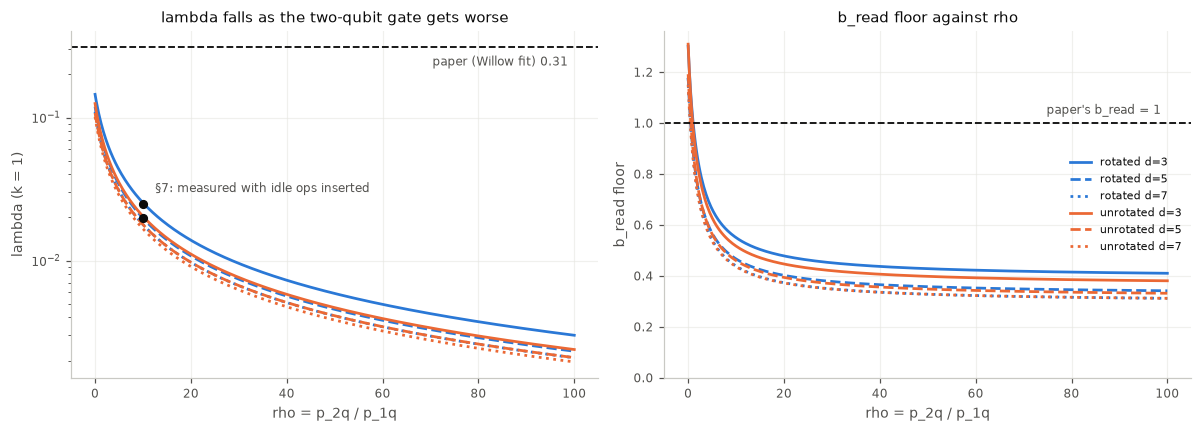

In [11]:
rho = np.linspace(0, 100, 401)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for (c, d), colour, ls in zip(SWEEP, [BLUE] * 3 + [ORANGE] * 3, ['-', '--', ':'] * 2):
    axes[0].plot(rho, [lam(c, d, r) for r in rho], color=colour, ls=ls, lw=1.8,
                 label=f'{c} d={d}')
    axes[1].plot(rho, [floor(c, d, r) for r in rho], color=colour, ls=ls, lw=1.8,
                 label=f'{c} d={d}')
for (c, d) in VAL_CODES:
    axes[0].plot(VAL_RHO, 1 / VAL[(c, d)]['icept'], 'o', color=INK, ms=5)
axes[0].annotate('§7: measured with idle ops inserted', (VAL_RHO, 1 / VAL[VAL_CODES[0]]['icept']),
                 xytext=(8, 8), textcoords='offset points', fontsize=8, color=MUTED)
axes[0].axhline(LAMBDA_PAPER, color=INK, lw=1.2, ls='--')
axes[0].annotate(f'paper (Willow fit) {LAMBDA_PAPER}', (100, LAMBDA_PAPER), xytext=(-4, -12), textcoords='offset points',
                 ha='right', fontsize=8, color=MUTED)
axes[0].set_yscale('log'); axes[0].set_ylabel('lambda (k = 1)')
axes[0].set_title('lambda falls as the two-qubit gate gets worse')
axes[1].axhline(B_READ_PAPER, color=INK, lw=1.2, ls='--')
axes[1].annotate(f"paper's b_read = {B_READ_PAPER:g}", (100, B_READ_PAPER), xytext=(-4, 6),
                 textcoords='offset points', ha='right', fontsize=8, color=MUTED)
axes[1].set_ylim(0, None); axes[1].set_ylabel('b_read floor')
axes[1].set_title('b_read floor against rho')
for a in axes:
    a.set_xlabel('rho = p_2q / p_1q'); a.grid(alpha=.6); a.set_axisbelow(True)
axes[1].legend(fontsize=7)
finish(fig, '04c_p2q_a_lambda_vs_rho')

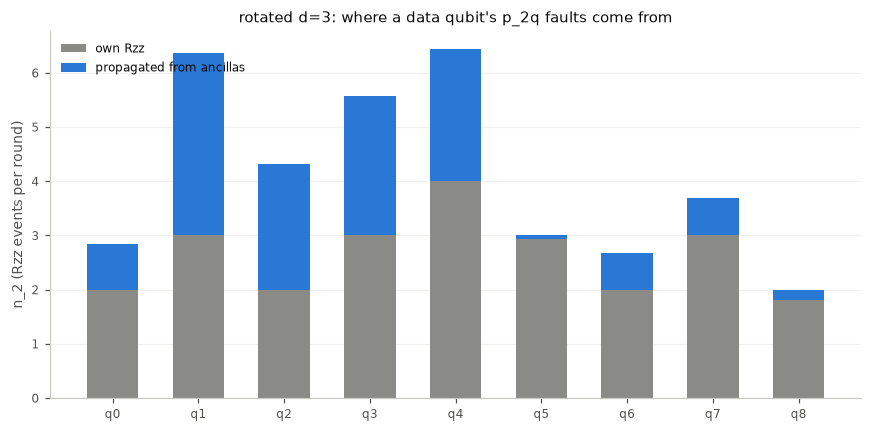

In [12]:
c0, d0 = "rotated", 3
f0 = FIT[(c0, d0)]
own = COMPILED[(c0, d0)]['rzz']
x = np.arange(len(own))
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x, own, width=0.6, color=GRAY, label='own Rzz')
ax.bar(x, f0['n2'] - own, bottom=own, width=0.6, color=BLUE, label='propagated from ancillas')
ax.set_xticks(x, [f'q{i}' for i in x]); ax.set_ylabel('n_2 (Rzz events per round)')
ax.set_title(f'{c0} d={d0}: where a data qubit\'s p_2q faults come from')
ax.grid(axis='y', alpha=.6); ax.set_axisbelow(True); ax.legend(loc='upper left')
finish(fig, '04c_p2q_b_n2_per_qubit')

## 10. Findings

**1. Each CNOT compiles to one `Rzz`, and `n_2` is 1.5–1.7× that count.** A data qubit sees
faults on its own `Rzz` plus 1.4–2.6 events per round propagated from X-check ancillas, which
are CNOT controls and copy an X or Y onto every data qubit they target afterwards. The
phenomenological model has no term for these.

**2. `p_1q` and `p_2q` add on a surface code**: measured rates at R = 4 match independent
composition within 0.4σ on all six codes, even with propagation present. So λ can be built
from `n_1` and `n_2`.

**3. This route can only lower λ.** At `k = 1`, λ is largest at ρ = 0 (0.10–0.15, 04's value)
and falls monotonically: 0.017–0.025 at ρ = 10, 0.0020–0.0030 at ρ = 100. A worse two-qubit
gate makes a round costlier relative to idling, which pushes the optimal interval longer.

**4. The paper's 0.31 needs `k > 1` for any ρ**: `k` = 2.1–3.1 at ρ = 0, 12–19 at ρ = 10. The gate
ratio cannot supply it; the idle unit must. That matches the physics: the paper's λ is idle
decoherence (T1/T2) per cycle time, which here is `k·f_1`, not a gate error.

**5. The formula predicts a circuit that idles.** With idle ops inserted at ρ = 10, the slope in
τ is 1.07 (rotated d = 3) and 1.03 (d = 5), and measured λ is 0.0247 and 0.0199 against
predicted 0.0253 and 0.0198: within 2.4% and 0.5%.

**6. The `b_read` floor falls with ρ**: 1.15–1.31 at ρ = 0, 0.86–1.01 at ρ = 1, 0.31–0.41 at
ρ = 100. `p_2q` loads the data far more than the Z-ancilla (`n_2,anc` = 1.59–1.86 against
`n_2` = 4.07–6.27), so the paper's `b_read = 1` is reached between ρ = 0 and ρ = 1.

### Limits

- **X faults only**, Z-basis readout.
- **Marginals only.** `p_2q` creates correlated data–ancilla and data–data faults; `n_2` counts
  them per qubit, but which qubits fail together is not recorded, and the decoder priors in
  `surface_memory.Geometry.priors` treat each data qubit independently.
- **Per-qubit `n_2` is noisy.** Two qubits in rotated d = 3 (q5 at 2.94, q8 at 1.81) fit
  slightly below their own `Rzz` count (3 and 2). λ and the export use per-code means.
- **The `b_read` floor is an upper bound**, as in 04.
- **Additivity is checked at R = 4 only**, and the §7 validation covers two codes at one ρ.

### Next

1. Derive `k` from T1/T2 and the cycle time for a given device (`k = p_mem(τ unit) / f_1`),
   as the paper's SM J does for λ. (`scripts/interval_analysis.py --k` already sweeps `k`.)
2. Record which qubits fail together once `p_2q` is on, so the decoder can weight correlated
   faults.